In [1]:
using PyPlot
using JLD2
using Statistics
using ProgressBars
using Images, ImageFiltering, Rotations, ImageTransformations, CoordinateTransformations
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful

In [ ]:
function mask_ellipse(xc, yc, a, b, θ, width, height)
    mask = zeros(Integer, (width, height))
    X = range(0, height-1) .- yc
    Y = range(0, width-1) .- xc
    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 1
            end
        end
    end
    return mask
end

function mask_stripes(img, centers, major_axis, minor_axis)
    mask = zeros(size(img))
    for (i, c) in enumerate(centers)
        mask .+= mask_ellipse(c[1], c[2], major_axis[i][1], minor_axis[i][1], 0, size(img)[1], size(img)[2])
    end
    mask[mask .> 0] .= true
    return img.*mask
end

function rotate_img_stripe_angle(img)
    """ Finds the angle at which the stripes are along the horizontal axis,
    ie where a sum along the horizontal axis is maximal """
    θ_range = [0:0.1:π/2;]

    Maximum_hor_mean = zeros(length(θ_range))

    for (i, θ) in enumerate(θ_range)
        trfm = recenter(RotMatrix(θ), center(img))
        imgw = warp(img, trfm)
        imgw[isnan.(imgw)] .= 0 # Padd the NaN values to 0

        Maximum_hor_mean[i] = maximum(sum(imgw, dims=2))
    end
    return θ_range[argmax(Maximum_hor_mean)]
end

function find_rotate_angle_stripes(img)
    """ Find the angle of the stripes and return the image rotated by this angle 
    so that the stripes are along the horizontal axis, and the angle as a 2nd argument """
    θ = rotate_img_stripe_angle(img)
    trfm = recenter(RotMatrix(θ), center(img))
    imgw = parent(warp(img, trfm))
    imgw[isnan.(imgw)] .= 0 # Padd the NaN values to 0
    return imgw, θ
end

find_rotate_angle_stripes (generic function with 1 method)

In [3]:
pathdir = "Y:/TwoDGas/2026/02/06/0000" # Stripes 60°

@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds
@load "Saved_exp_data/Stripes_"*join(split(pathdir, "/")[3:end], "_")*".jld2" centers_stripes_ds major_axis_stripes_ds minor_axis_stripes_ds nbr_stripes_ds
# size_pxl = 0.187e-6
size_pxl = 0.1966e-6; # New pxl size since 2025/12/31

### Check validity of droplet region

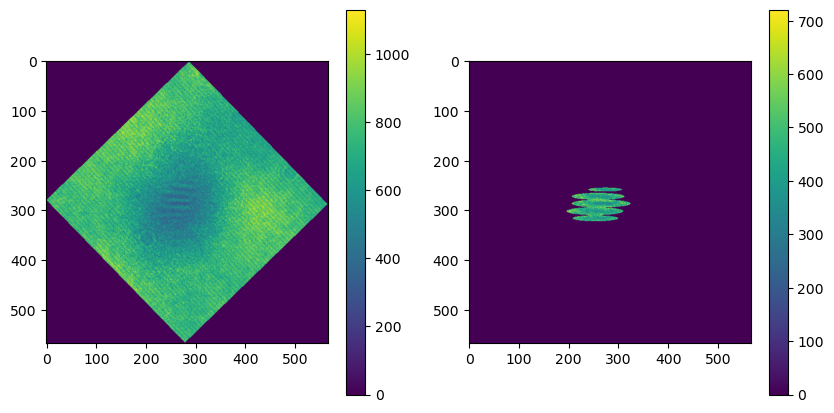

In [4]:
i, j = 4, 4

close("all")
fig, axs = subplots(1, 2, figsize=(10, 5))

img_rot = find_rotate_angle_stripes(Imgs_atoms_crop_ds[i, j, :, :])[1]

img1 = axs[1].imshow(img_rot)
colorbar(img1)

if nbr_stripes_ds[i, j] > 0
    img2 = axs[2].imshow(mask_stripes(img_rot, centers_stripes_ds[i][j], major_axis_stripes_ds[i][j], minor_axis_stripes_ds[i][j]))#, vmin=minimum(Imgs_atoms_crop_ds[i, j, :, :]), vmax=maximum(Imgs_atoms_crop_ds[i, j, :, :]))
    colorbar(img2)
end

# pygui(true); show()
pygui(false);

In [5]:
print(sum(mask_stripes(img_rot, centers_stripes_ds[i][j], major_axis_stripes_ds[i][j], minor_axis_stripes_ds[i][j])))

2.4471541268819775e6

In [6]:
print(sum(mask_stripes(img_rot, centers_stripes_ds[i][j], major_axis_stripes_ds[i][j], minor_axis_stripes_ds[i][j])))

2.4471541268819775e6

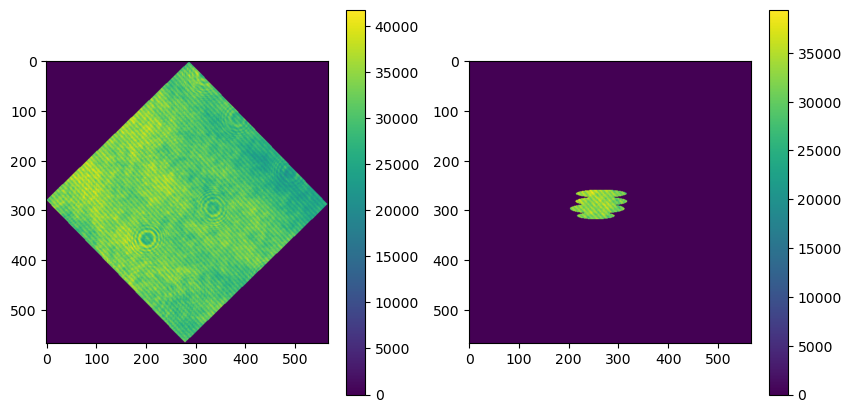

In [7]:
i, j = 19, 10

close("all")
fig, axs = subplots(1, 2, figsize=(10, 5))

img_rot = find_rotate_angle_stripes(Imgs_bkg_crop_ds[i, j, :, :])[1]

img1 = axs[1].imshow(img_rot)
colorbar(img1)

if nbr_stripes_ds[i, j] > 0
    img2 = axs[2].imshow(mask_stripes(img_rot, centers_stripes_ds[i][j], major_axis_stripes_ds[i][j], minor_axis_stripes_ds[i][j]))#, vmin=minimum(Imgs_atoms_crop_ds[i, j, :, :]), vmax=maximum(Imgs_atoms_crop_ds[i, j, :, :]))
    colorbar(img2)
end

# pygui(true); show()
pygui(false);

### Intensity integrated over the stripes

In [ ]:
centers_stripes_ds[5][1][1]

2-element Vector{Float64}:
 258.9265306122449
 299.82448979591834

In [26]:
major_axis_stripes_ds[5][1][1]

1-element Vector{Int64}:
 63

In [29]:
major_axis_stripes_ds[5][1][1][1]

63

In [ ]:
Iatoms_stripes, Ibkg_stripes, Idark_stripes = zeros(size(Imgs_atoms_crop_ds)[1:2]), zeros(size(Imgs_atoms_crop_ds)[1:2]), zeros(size(Imgs_atoms_crop_ds)[1:2])

# Convertion factor to go from electrons to photons
if length(τ_exp) == 1
    Convertion_factor = 0.107 / (0.85 * τ_exp)
end

for i = ProgressBar(1:size(Imgs_atoms_crop_ds)[1])
    if length(τ_exp) > 1
        Convertion_factor = 0.107 / (0.85 * τ_exp[i])
    end

    for j = 1:size(Imgs_atoms_crop_ds)[2]
        
        if nbr_stripes_ds[i, j] > 0
            img_atoms_rot = find_rotate_angle_stripes(Imgs_atoms_crop_ds[i, j, :, :])[1]
        end

        for k in 1:Int(nbr_stripes_ds[i, j]) # As the surface is different for each stripe, we have to add the intensity for each one of them
            
            S_stripe = π * major_axis_stripes_ds[i][j][k][1]*minor_axis_stripes_ds[i][j][k][1] * size_pxl^2
            mask_stripe = mask_ellipse(centers_stripes_ds[i][j][k][1], centers_stripes_ds[i][j][k][2], major_axis_stripes_ds[i][j][k][1], minor_axis_stripes_ds[i][j][k][1], 0, size(img_rot)[1], size(img_rot)[2])

            println(size(mask_stripe))
            println(size(Imgs_atoms_crop_ds))

            Iatoms_stripes[i, j] += mask_stripe .* Imgs_atoms_crop_ds[i, j, :, :] * Convertion_factor / S_stripe
            Ibkg_stripes[i, j] += mask_stripe .* Imgs_bkg_crop_ds[i, j, :, :] * Convertion_factor / S_stripe
            Idark_stripes[i, j] += mask_stripe .* Imgs_dark_crop_ds[i, j, :, :] * Convertion_factor / S_stripe
        end
    end
end

0.0%┣                                               ┫ 0/19 [00:00<00:00, -0s/it]


(567, 567)
(19, 20, 401, 401)


LoadError: DimensionMismatch: arrays could not be broadcast to a common size: a has axes Base.OneTo(567) and b has axes Base.OneTo(401)

In [ ]:
S_stripes = 0
for k in 1:length(major_axis_stripes_ds[i][j])
    S_stripes += π*major_axis_stripes_ds[i][j][k][1]*minor_axis_stripes_ds[i][j][k][1]*size_pxl^2
end

### Compute mean/std

In [9]:
Mean_atoms, Mean_bkg, Mean_dark, Mean_bkg_atoms = zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat))
Std_atoms, Std_bkg, Std_dark, Std_bkg_atoms = zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat))

for i = 1:length(Sat)
    atoms, bkg, dark, bkg_atoms = [], [], [], []
    for j = 1:size(Imgs_atoms_crop_ds)[2]
        if nbr_stripes_ds[i, j] > 0
            push!(atoms, Iatoms_stripes[i, j]), push!(bkg, Ibkg_stripes[i, j]), push!(dark, Idark_stripes[i, j]), push!(bkg_atoms, Ibkg_stripes[i, j]-Iatoms_stripes[i, j])
        end
    end
    if length(atoms) > 0
        Mean_atoms[i], Mean_bkg[i], Mean_dark[i], Mean_bkg_atoms[i] = mean(atoms), mean(bkg), mean(dark), mean(bkg_atoms)
        Std_atoms[i], Std_bkg[i], Std_dark[i], Std_bkg_atoms[i] = std(atoms), std(bkg), std(dark), std(bkg_atoms)
    end
end

## Plots

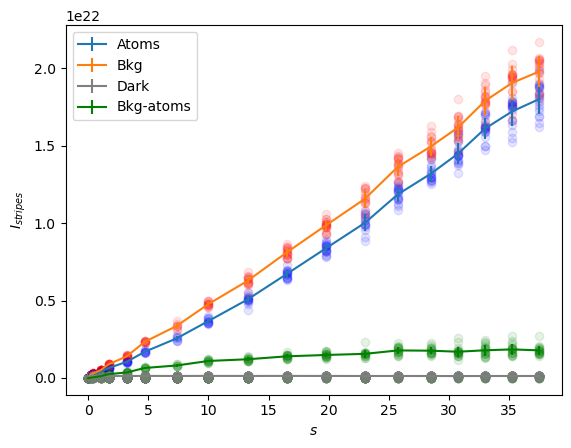

In [11]:
close("all")
fig = subplots()

errorbar(Sat, Mean_atoms, yerr=Std_atoms, label="Atoms")
errorbar(Sat, Mean_bkg, yerr=Std_bkg, label="Bkg")
errorbar(Sat, Mean_dark, yerr=Std_dark, label="Dark", color="grey")
errorbar(Sat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Bkg-atoms", color="g")


for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        scatter(Sat[i], Iatoms_stripes[i, j], color="b", alpha = 0.1)
        scatter(Sat[i], Ibkg_stripes[i, j], color="r", alpha = 0.1)
        scatter(Sat[i], Idark_stripes[i, j], color="grey")
        scatter(Sat[i], Ibkg_stripes[i, j]-Iatoms_stripes[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{stripes}")

legend()

# pygui(true); show();
pygui(false);

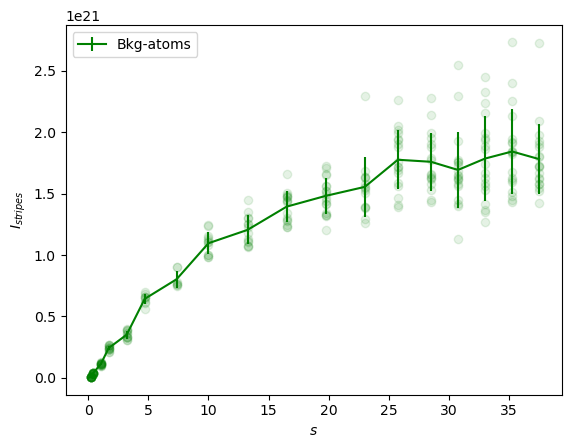

In [12]:
close("all")
fig = subplots()

errorbar(Sat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Bkg-atoms", color="g")

for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        if nbr_stripes_ds[i, j] > 0
            scatter(Sat[i], Ibkg_stripes[i, j]-Iatoms_stripes[i, j], color="g", alpha = 0.1)
        end
    end
end

xlabel(L"s")
ylabel(L"I_{stripes}")

legend()

# pygui(true); show();
pygui(false);

In [ ]:
close("all")
fig = subplots()

errorbar(Sat, Mean_atoms, yerr=Std_atoms, label="Atoms")


for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        if nbr_stripes_ds[i, j] > 0
            scatter(Sat[i], Iatoms_stripes[i, j], color="b", alpha = 0.1)
        end
    end
end

xlabel(L"s")
ylabel(L"I_{stripes}")

legend()

# pygui(true); show();
pygui(false);

### Save data

In [14]:
@save "Saved_exp_data/Intensity_integrated_stripes_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat Iatoms_stripes Ibkg_stripes Idark_stripes Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms;

In [ ]:
@load "Saved_exp_data/Intensity_integrated_stripes_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat Iatoms_stripes Ibkg_stripes Idark_stripes Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark 
Γ = 2.02e8 # In Hz
λ = 421e-9
ω0 = 2π*ustrip(c_0)/λ

Isat = Γ*ω0^2 / (12*π*ustrip(c_0)^2) # In photon/m^2

errorbar(Mean_bkg/Isat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Bkg-atoms", color="green")
errorbar(Mean_bkg/Isat, Mean_atoms, yerr=Std_atoms, label="Atoms")
errorbar(Mean_bkg/Isat, Mean_bkg, yerr=Std_bkg, label="Bkg")
errorbar(Mean_bkg/Isat, Mean_dark, yerr=Std_dark, label="Dark", color="grey")

for i = 1:size(Iatoms_stripes)[1]
    for j = 1:size(Iatoms_stripes)[2]
        scatter(Ibkg_stripes[i, j]/Isat, Ibkg_stripes[i, j]-Iatoms_stripes[i, j], color="g", alpha = 0.1)
        scatter(Ibkg_stripes[i, j]/Isat, Iatoms_stripes[i, j], color="b", alpha = 0.1)
        scatter(Ibkg_stripes[i, j]/Isat, Ibkg_stripes[i, j], color="r", alpha = 0.1)
        scatter(Ibkg_stripes[i, j]/Isat, Idark_stripes[i, j], color="grey")
        scatter(Ibkg_stripes[i, j]/Isat, Ibkg_stripes[i, j]-Iatoms_stripes[i, j], color="g", alpha = 0.1)
    end
end;

LoadError: LoadError: MethodError: [0mCannot `convert` an object of type [92mExpr[39m[0m to an object of type [91mSymbol[39m
The function `convert` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  Symbol(::Any...)
[0m[90m   @[39m [90mBase[39m [90mstrings/[39m[90m[4mbasic.jl:229[24m[39m
[0m  convert(::Type{Symbol}, [91m::PyCall.PyObject[39m)
[0m[90m   @[39m [36mPyCall[39m [90m~/.julia/packages/PyCall/1gn3u/src/[39m[90m[4mconversions.jl:107[24m[39m
[0m  convert(::Type{Symbol}, [91m::JSON.PtrString[39m)
[0m[90m   @[39m [32mJSON[39m [90m~/.julia/packages/JSON/0oqO1/src/[39m[90m[4mlazy.jl:435[24m[39m
[0m  ...

in expression starting at In[13]:1

### Plot as a function of the calculated saturation parameter

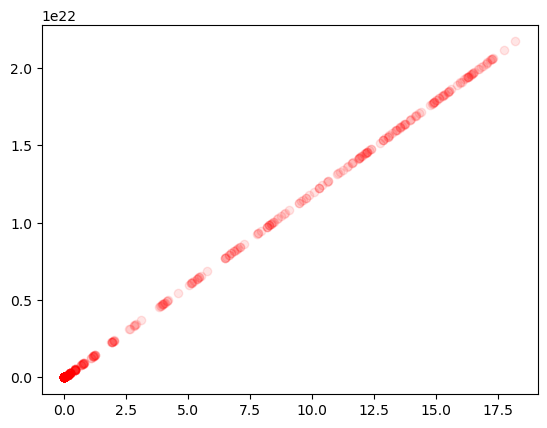

In [15]:
Γ = 2.02e8 # In Hz
λ = 421e-9
ω0 = 2π*ustrip(c_0)/λ

Isat = Γ*ω0^2 / (12*π*ustrip(c_0)^2) # In photon/m^2

# errorbar(Mean_bkg/Isat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Bkg-atoms", color="green")
# errorbar(Mean_bkg/Isat, Mean_atoms, yerr=Std_atoms, label="Atoms")
# errorbar(Mean_bkg/Isat, Mean_bkg, yerr=Std_bkg, label="Bkg")
# errorbar(Mean_bkg/Isat, Mean_dark, yerr=Std_dark, label="Dark", color="grey")

for i = 1:size(Iatoms_stripes)[1]
    for j = 1:size(Iatoms_stripes)[2]
        # scatter(Ibkg_stripes[i, j]/Isat, Ibkg_stripes[i, j]-Iatoms_stripes[i, j], color="g", alpha = 0.1)
        # scatter(Ibkg_stripes[i, j]/Isat, Iatoms_stripes[i, j], color="b", alpha = 0.1)
        scatter(Ibkg_stripes[i, j]/Isat, Ibkg_stripes[i, j], color="r", alpha = 0.1)
#         scatter(Ibkg_stripes[i, j]/Isat, Idark_stripes[i, j], color="grey")
#         scatter(Ibkg_stripes[i, j]/Isat, Ibkg_stripes[i, j]-Iatoms_stripes[i, j], color="g", alpha = 0.1)
    end
end


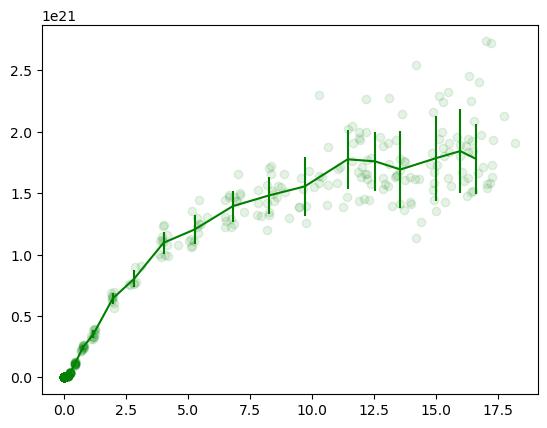

In [16]:
Γ = 2.02e8 # In Hz
λ = 421e-9
ω0 = 2π*ustrip(c_0)/λ

Isat = Γ*ω0^2 / (12*π*ustrip(c_0)^2) # In photon/m^2

errorbar(Mean_bkg/Isat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Bkg-atoms", color="green")

for i = 1:size(Iatoms_stripes)[1]
    for j = 1:size(Iatoms_stripes)[2]
        scatter(Ibkg_stripes[i, j]/Isat, Ibkg_stripes[i, j]-Iatoms_stripes[i, j], color="g", alpha = 0.1)
    end
end